In [1]:
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt


In [2]:
# load .mat dataset
matdata  = sp.io.loadmat("data/Visualization_Dataset_copy1.mat", squeeze_me=True, struct_as_record=True)

for key in matdata:
    if not key.startswith("__"):
        print(key, matdata[key].shape)

print("-"*40)

P_all (267,)
amplitude_all (267,)
frequency (49902,)
m_dot_all (267,)
signal_all (267,)
----------------------------------------


In [3]:
# Hyperparameters 
fs = 48000 # Hz

# assign each variable
P_all = matdata["P_all"]
amplitude_all = matdata["amplitude_all"]
frequency = matdata["frequency"]
m_dot_all = matdata["m_dot_all"]
signal_all = matdata["signal_all"]

# see how each variable was unpacked
print("SHAPES OF UNPACKED VARIABLES - Chosen: Amplitude")
print(f"Amplitude shape: {amplitude_all.shape}")
print(f"Amplitude Dimension: {amplitude_all.ndim}")
print(f"Amplitude dtype: {amplitude_all.dtype}")

print("-"*40)

SHAPES OF UNPACKED VARIABLES - Chosen: Amplitude
Amplitude shape: (267,)
Amplitude Dimension: 1
Amplitude dtype: object
----------------------------------------


In [5]:
# make the spectrum 1D and add them vertically
amplitude_all = np.vstack([
    amplitude_all[i].flatten()
    for i in range(len(amplitude_all))
])

signal_all = np.vstack([
    sig.flatten()
    for sig in signal_all
])

# verification with amplitude
print("Verification that amplitude was correctly added vertically")
print(f"Amplitude Shape: {amplitude_all.shape}")
print(f"Amplitude Dimension: {amplitude_all.ndim}")
print(f"Amplitude dtype: {amplitude_all.dtype}")
print("Verification that signals were correctly added vertically")
print(f"Signal Shape: {signal_all.shape}")
print(f"Signal Dimension: {signal_all.ndim}")
print(f"Signal Data Type: {signal_all.dtype}")
print("_"*40)

Verification that amplitude was correctly added vertically
Amplitude Shape: (267, 49902)
Amplitude Dimension: 2
Amplitude dtype: float64
Verification that signals were correctly added vertically
Signal Shape: (267, 100000)
Signal Dimension: 2
Signal Data Type: float64
________________________________________


In [6]:
# extraction of peak frequencies
f_min = 100
f_max = 20000

mask = (frequency >= f_min) & (frequency <= f_max)

freq_crop = frequency[mask]
spectra_crop = amplitude_all[:, mask]
spectra_log = 20*np.log10(spectra_crop + 1e-12)
spectra_norm = spectra_log - np.max(spectra_log)

print("MINIMUM AND MAXIMUM OF NORMALIZED SPECTRA")
print(f"Minimum of normalized spectra: {spectra_norm.min()}")
print(f"Maximum of normalized spectra: {spectra_norm.max()}")
print("_"*40)

MINIMUM AND MAXIMUM OF NORMALIZED SPECTRA
Minimum of normalized spectra: -135.8733382259335
Maximum of normalized spectra: 0.0
________________________________________


In [7]:
total_samples = len(m_dot_all)
tdx_list = np.random.choice(total_samples, size = 6, replace=False)   # select 6 random recordings to look at (i.e., index)
tdx_list_sorted = np.argsort(tdx_list)
tdx_personalized = [] # fill list if specific values are wanted - 6 inputs required. 

print(f"Total Samples: {total_samples}")
print(f"Plotting indices: {tdx_list}")
print("-"*40)

Total Samples: 267
Plotting indices: [226 161  22 204  88 242]
----------------------------------------


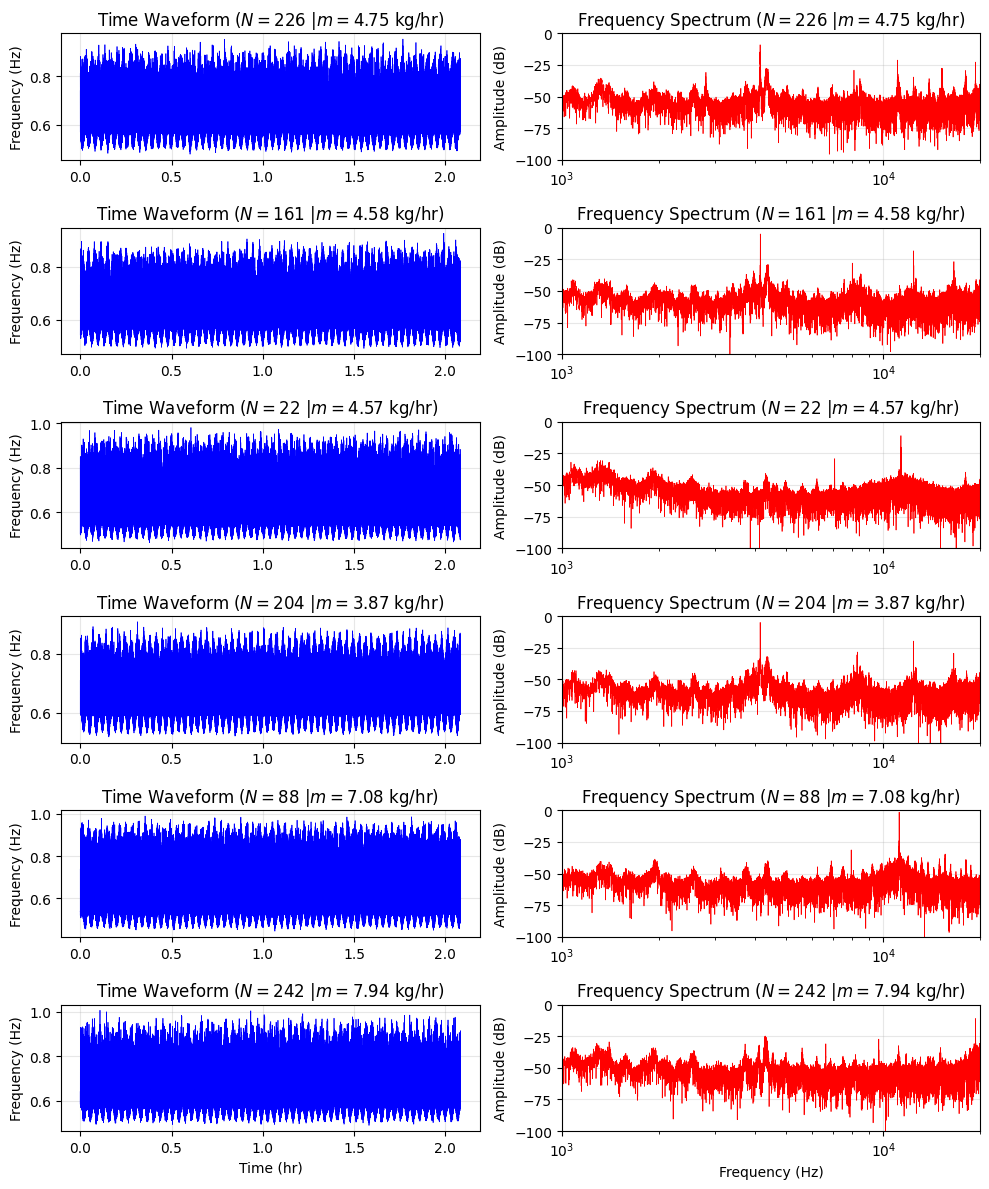

In [8]:
# plotting


fig, axs = plt.subplots(6, 2, figsize=(10, 12))

# loop through selected indices and populate subplots
for i, tdx in enumerate(tdx_list): 
    sig_time = signal_all[tdx]
    flow_val = m_dot_all[tdx]
    amp_spectrum = spectra_norm[tdx]

    duration = len(sig_time) / fs
    t_list = np.linspace(0, duration, len(sig_time))

    # Time acoustic domain
    axs[i, 0].plot(t_list, sig_time, color='b', linewidth=0.5)
    axs[i, 0].set_ylabel("Frequency (Hz)")
    axs[i, 0].set_title(f"Time Waveform ($N ={tdx}$ |$m = {flow_val:.2f}$ kg/hr)")
    axs[i, 0].grid(True, alpha=0.3)

    # Frequency spectrum
    axs[i, 1].plot(freq_crop, amp_spectrum, color='r', linewidth=0.5)
    axs[i, 1].set_ylabel("Amplitude (dB)")
    axs[i, 1].set_title(f"Frequency Spectrum ($N ={tdx}$ |$m = {flow_val:.2f}$ kg/hr)")
    axs[i, 1].grid(True, alpha=0.3)

    axs[i, 1].set_xlim(1000, 20000)
    axs[i, 1].set_ylim(-100, 0)
    axs[i, 1].set_xscale('log')

axs[-1, 0].set_xlabel("Time (hr)")
axs[-1, 1].set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_11367/3053382244.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


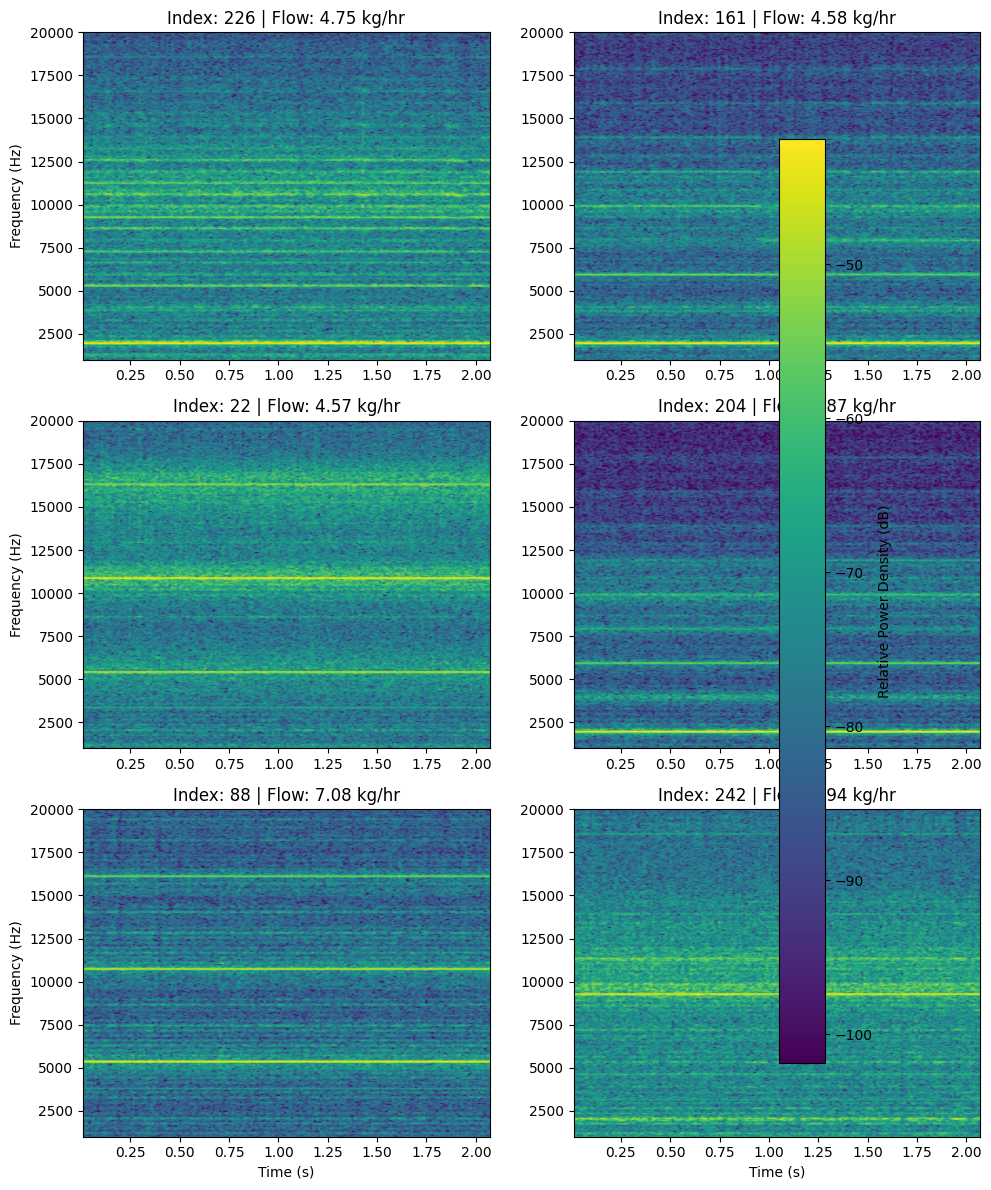

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(10, 12))

# plot spectrogram i.e., frequency v time 
for i, tdx in enumerate(tdx_list): 
    sig_time = signal_all[tdx]
    flow_val = m_dot_all[tdx]

    # calculate spectrogram 
    f_spec, t_spec, Sxx = sp.signal.spectrogram(sig_time, 
                                                fs = fs,
                                                nperseg = 1024, 
                                                noverlap = 512, 
                                                window = 'hann')
    
    Sxx_db = 10*np.log10(Sxx + 1e-12)

    # Plot on the specific subplot (axs_flat[i])
    mesh = axs.flat[i].pcolormesh(t_spec, f_spec, Sxx_db, 
                                  shading='gouraud', 
                                  cmap='viridis', 
                                  vmin=np.max(Sxx_db) - 60, # Keep a 60 dB dynamic range
                                  vmax=np.max(Sxx_db))
    
    # Title for each subplot
    axs.flat[i].set_title(f"Index: {tdx} | Flow: {flow_val:.2f} kg/hr")
    axs.flat[i].set_ylim(1000, 20000) # Focus on whistle frequencies

# clean up labels
for ax in axs[-1, :]:
    ax.set_xlabel("Time (s)")
for ax in axs[:, 0]:
    ax.set_ylabel("Frequency (Hz)")

fig.colorbar(mesh, ax=axs.ravel().tolist(), label="Relative Power Density (dB)")
plt.tight_layout()
plt.show()

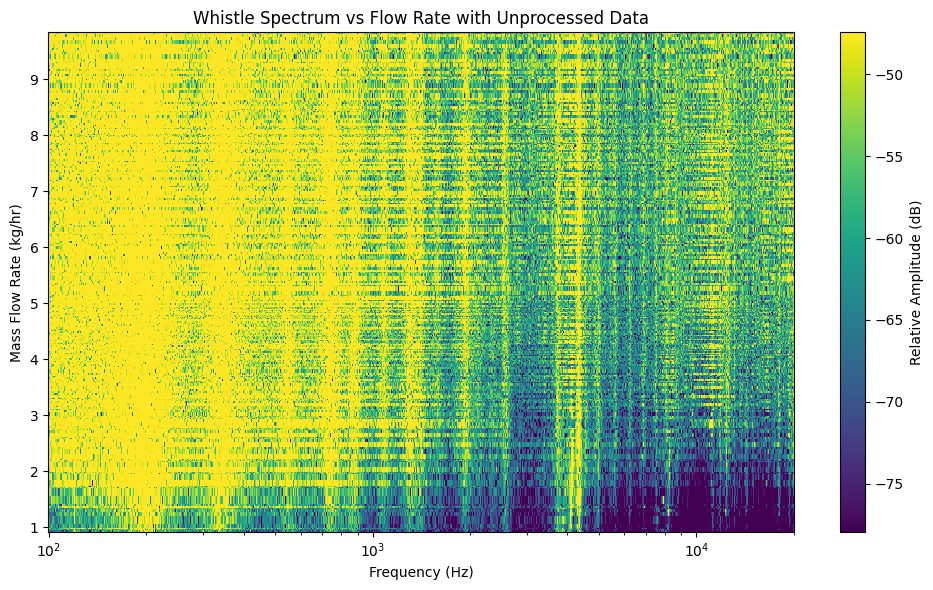

In [10]:
idx = np.argsort(m_dot_all) # sort all mass flow rates

peak_idx = np.argmax(spectra_crop, axis=1) # i.e., maximum frequency
f_peak = freq_crop[peak_idx]

flow_sorted = m_dot_all[idx]
spectra_sorted = spectra_norm[idx]

vmin = np.percentile(spectra_sorted, 5)
vmax = np.percentile(spectra_sorted, 90)

plt.figure(figsize=(10,6))
plt.pcolormesh(freq_crop,
               flow_sorted,
               spectra_sorted,
               shading='auto', 
               vmin=vmin, 
               vmax=vmax)
plt.xscale('log')
plt.ylabel("Mass Flow Rate (kg/hr)")
plt.xlabel("Frequency (Hz)")
plt.colorbar(label="Relative Amplitude (dB)")
plt.title("Whistle Spectrum vs Flow Rate with Unprocessed Data")
plt.tight_layout()
plt.show()

In [11]:
# fast fourier transforms using Welch's method
sampling_rate = 48000 # Hz 
Pxx_list = [] # initialize pxx 

for sig in signal_all:
    # implement nperseg to control frequency resolution (higher = more detail and noise)
    f, Pxx = sp.signal.welch(sig, fs=sampling_rate, nperseg=4096, window='hann') 
    Pxx_list.append(Pxx)

Pxx_all = np.array(Pxx_list)

# convert power to decibels dB
psd_db = 10*np.log10(Pxx_all + 1e-12)

# normalize relative to global peak 
psd_norm = psd_db - np.max(psd_db)
psd_sorted = psd_norm[idx]#sort psd

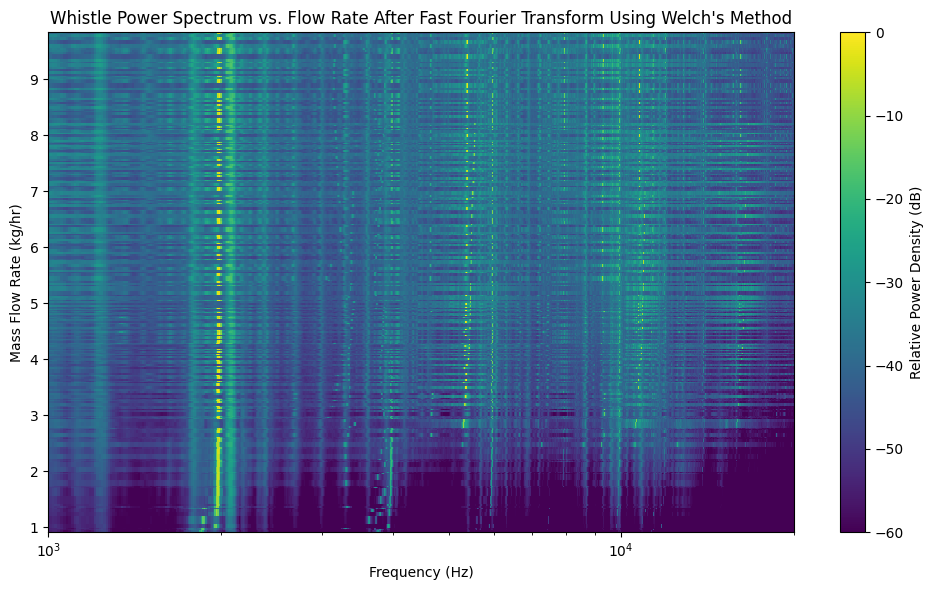

In [12]:
# Plot: freq (X), flow (Y), psd(Z)
plt.figure(figsize=(10,6))
plt.pcolormesh(f, flow_sorted, psd_sorted, 
               shading='auto', 
               vmin = -60, vmax = 0, # limit noise to -60 dB for clarity
               cmap = 'viridis'
               )
plt.xscale('log')
plt.xlim(1000, 20000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Mass Flow Rate (kg/hr)")
plt.colorbar(label="Relative Power Density (dB)")
plt.title("Whistle Power Spectrum vs. Flow Rate After Fast Fourier Transform Using Welch's Method")
plt.tight_layout()
plt.show()